# 3. Entrenamiento, Diagnóstico y Exportación de Modelos

Este cuaderno desglosa paso a paso la arquitectura de Machine Learning elegida para FinanceAI. Entrenaremos dos modelos fundamentales:
1. **Clasificador NLP de Transacciones:** (FeatureUnion + LinearSVC calibrado)
2. **Perfilador de Riesgo Financiero:** (HistGradientBoostingClassifier)

In [1]:
# =============================================================================
# 1. IMPORTACION DE LIBRERIAS Y CONFIGURACION DE ENTORNO DE ENTRENAMIENTO
# =============================================================================
import os
import re
import unicodedata

# 'joblib' se utiliza para serializar y guardar los modelos entrenados en disco de forma eficiente
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Modulos especificos de Scikit-Learn para el pipeline de Machine Learning:
# - 'CalibratedClassifierCV': Calibra las distancias de la SVM en probabilidades [0.0, 1.0] usando escalado de Platt
from sklearn.calibration import CalibratedClassifierCV

# - 'HistGradientBoostingClassifier': Algoritmo de ensamble por arboles de gradiente acelerado para perfiles financieros
from sklearn.ensemble import HistGradientBoostingClassifier

# - 'TfidfVectorizer': Transforma texto en matrices numericas basadas en frecuencia de terminos e inversa de documentos
from sklearn.feature_extraction.text import TfidfVectorizer

# - 'permutation_importance': Evalua la importancia de variables midiendo el deterioro del modelo al barajar cada columna
from sklearn.inspection import permutation_importance

# - 'classification_report', 'confusion_matrix': Metricas estandares para evaluacion cuantitativa de modelos
from sklearn.metrics import classification_report, confusion_matrix

# - 'FeatureUnion': Concatena multiples extractores de caracteristicas en un solo flujo en paralelo
# - 'Pipeline': Encadena etapas secuenciales de preprocesamiento, vectorizacion y estimacion
from sklearn.pipeline import FeatureUnion, Pipeline

# - 'StandardScaler': Normaliza variables continuas para que tengan media 0 y varianza 1
from sklearn.preprocessing import StandardScaler

# - 'LinearSVC': Support Vector Machine lineal, altamente eficiente para clasificacion de texto en alta dimension
from sklearn.svm import LinearSVC

# Configuramos estilo grafico y rutas de artefactos para el microservicio de FastAPI
sns.set_theme(style="white")
DATA_DIR = "data"
ARTIFACTS_DIR = "../services/ml-service/app/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("Librerias importadas y directorio de artefactos verificado.")


Librerias importadas y directorio de artefactos verificado.


## 3.1 Carga de Datos y Preprocesamiento de Texto
Cargamos las transacciones y demostramos cómo nuestra función de limpieza normaliza los caracteres problemáticos antes del modelado.

In [2]:
# =============================================================================
# 2. CARGA DE DATOS Y FUNCION DE NORMALIZACION DE TEXTO
# =============================================================================
df_t = pd.read_csv(f"{DATA_DIR}/transacciones.csv")

# Separamos estrictamente segun la columna 'split' para respetar la particion temporal Out-of-Time
train_df = df_t[df_t['split'] == 'train']
test_df = df_t[df_t['split'] == 'test']

def limpiar_texto(texto: str) -> str:
    """
    Normaliza cadenas de texto para NLP:
    1. Convierte a minusculas y elimina espacios sobrantes al inicio/final.
    2. Elimina tildes y caracteres diacriticos usando descomposicion Unicode NFKD.
    3. Remueve caracteres especiales (signos de puntuacion, simbolos monetarios, etc.).
    4. Colapsa multiples espacios consecutivos en un unico espacio.
    """
    if not isinstance(texto, str):
        return ""
    texto = texto.lower().strip()
    # Normalizacion Unicode: 'DÍA' -> 'DIA', 'CAFÉ' -> 'CAFE'
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    # Expresion regular: conserva solo letras a-z, digitos 0-9 y espacios
    texto = re.sub(r'[^a-zA-Z0-9\s]', ' ', texto)
    # Reemplaza secuencias de espacios por un solo espacio
    return re.sub(r'\s+', ' ', texto).strip()

# Demostracion del efecto de limpieza
ejemplo_sucio = "POS SUPERMERCAD0 DÍA %& SUC 14"
print(f"Original: {ejemplo_sucio}")
print(f"Limpio:   {limpiar_texto(ejemplo_sucio)}\n")

# Preparamos los vectores de caracteristicas (X) y etiquetas objetivo (y)
X_train = train_df['descripcion'].apply(limpiar_texto)
y_train = train_df['categoria']
X_test = test_df['descripcion'].apply(limpiar_texto)
y_test = test_df['categoria']
print(f"Conjunto de entrenamiento: {len(X_train)} ejemplos | Conjunto de prueba: {len(X_test)} ejemplos")


Original: POS SUPERMERCAD0 DÍA %& SUC 14
Limpio:   pos supermercad0 dia suc 14

Conjunto de entrenamiento: 23494 ejemplos | Conjunto de prueba: 5069 ejemplos


## 3.2 Arquitectura Híbrida: Palabras + Subpalabras (Char n-grams)
Utilizamos `FeatureUnion` para combinar dos enfoques:
1. **Tfidf (Words):** Captura el significado semántico directo (ej. 'supermercado').
2. **Tfidf (Char_wb):** Captura subsecuencias de caracteres (ej. 'super'). Esto confiere robustez ante errores ortográficos (ej. 'suprrmercado').

In [3]:
# =============================================================================
# 3. ARQUITECTURA HIBRIDA OPTIMIZADA Y BUSQUEDA DE HIPERPARAMETROS
# =============================================================================
from sklearn.model_selection import GridSearchCV, PredefinedSplit

DOMAIN_STOPWORDS = [
    'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'por', 'un', 'para',
    'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'mas', 'pero', 'sus', 'le',
    'ya', 'o', 'este', 'si', 'porque', 'esta', 'son', 'entre', 'esta', 'sobre',
    'compra', 'compras', 'pago', 'pagos', 'debito', 'automatico', 'db', 'aut',
    'trf', 'transferencia', 'pos', 'estab', 'cupon', 'suc', 'online', 'fact'
]

# Control de dimensionalidad: evitamos la explosion de memoria acotando max_features y min_df
union_features = FeatureUnion([
    ('word_tfidf', TfidfVectorizer(
        analyzer='word', ngram_range=(1, 2), stop_words=DOMAIN_STOPWORDS, 
        sublinear_tf=True, max_features=2500, min_df=2
    )),
    ('char_tfidf', TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3, 5), 
        sublinear_tf=True, max_features=5000, min_df=3
    ))
])

# Base LinearSVC (se tuneará el hiperparámetro C)
base_svc = LinearSVC(class_weight='balanced', random_state=42)
calibrated_clf = CalibratedClassifierCV(estimator=base_svc, method='sigmoid', cv=3)

nlp_pipeline = Pipeline([
    ('features', union_features),
    ('clf', calibrated_clf)
])

# Preparación para GridSearchCV usando PredefinedSplit (Train vs Val explícito)
# Concatenamos train y val para que GridSearch haga la busqueda sin usar test
df_train_val = df_t[df_t['split'].isin(['train', 'val'])].copy()
X_tv = df_train_val['descripcion'].apply(limpiar_texto)
y_tv = df_train_val['categoria']

# -1 indica entrenamiento, 0 indica validacion
split_indices = [-1 if s == 'train' else 0 for s in df_train_val['split']]
pds = PredefinedSplit(test_fold=split_indices)

# Definimos los valores posibles para el margen de SVM (C)
param_grid = {
    'clf__estimator__C': [0.1, 0.5, 1.0, 2.0]
}

print("Iniciando GridSearchCV para optimización de hiperparámetros (C)...")
grid_search = GridSearchCV(
    estimator=nlp_pipeline,
    param_grid=param_grid,
    cv=pds,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_tv, y_tv)
print(f"Mejor parámetro seleccionado empíricamente: {grid_search.best_params_}")

# Extraemos el mejor pipeline ya entrenado
best_nlp_model = grid_search.best_estimator_


Iniciando GridSearchCV para optimización de hiperparámetros (C)...
Mejor parámetro seleccionado empíricamente: {'clf__estimator__C': 0.5}


## 3.3 Diagnóstico del NLP: Reporte y Matriz de Confusión
Evaluamos el rendimiento en el conjunto de prueba *Out-of-Time* (transacciones de fin de año que el modelo nunca vio).

Reporte de Clasificación NLP (Métricas Cuantitativas por Clase):

                   precision    recall  f1-score   support

     Alimentacion     0.9227    0.9960    0.9579      1006
Creditos y Deudas     0.8872    0.7973    0.8398       582
        Educacion     0.8571    0.8222    0.8393       270
Electrodomesticos     0.8150    0.8316    0.8232       196
        Inversion     0.7429    0.9204    0.8222       314
             Ocio     0.9321    0.7225    0.8140       209
            Salud     0.8952    0.7866    0.8374       239
        Servicios     0.9086    0.7767    0.8375       627
       Transporte     1.0000    1.0000    1.0000       449
       Vestimenta     0.8750    0.7352    0.7990       219
         Vivienda     0.8310    0.9290    0.8773       958

         accuracy                         0.8810      5069
        macro avg     0.8788    0.8470    0.8589      5069
     weighted avg     0.8846    0.8810    0.8795      5069



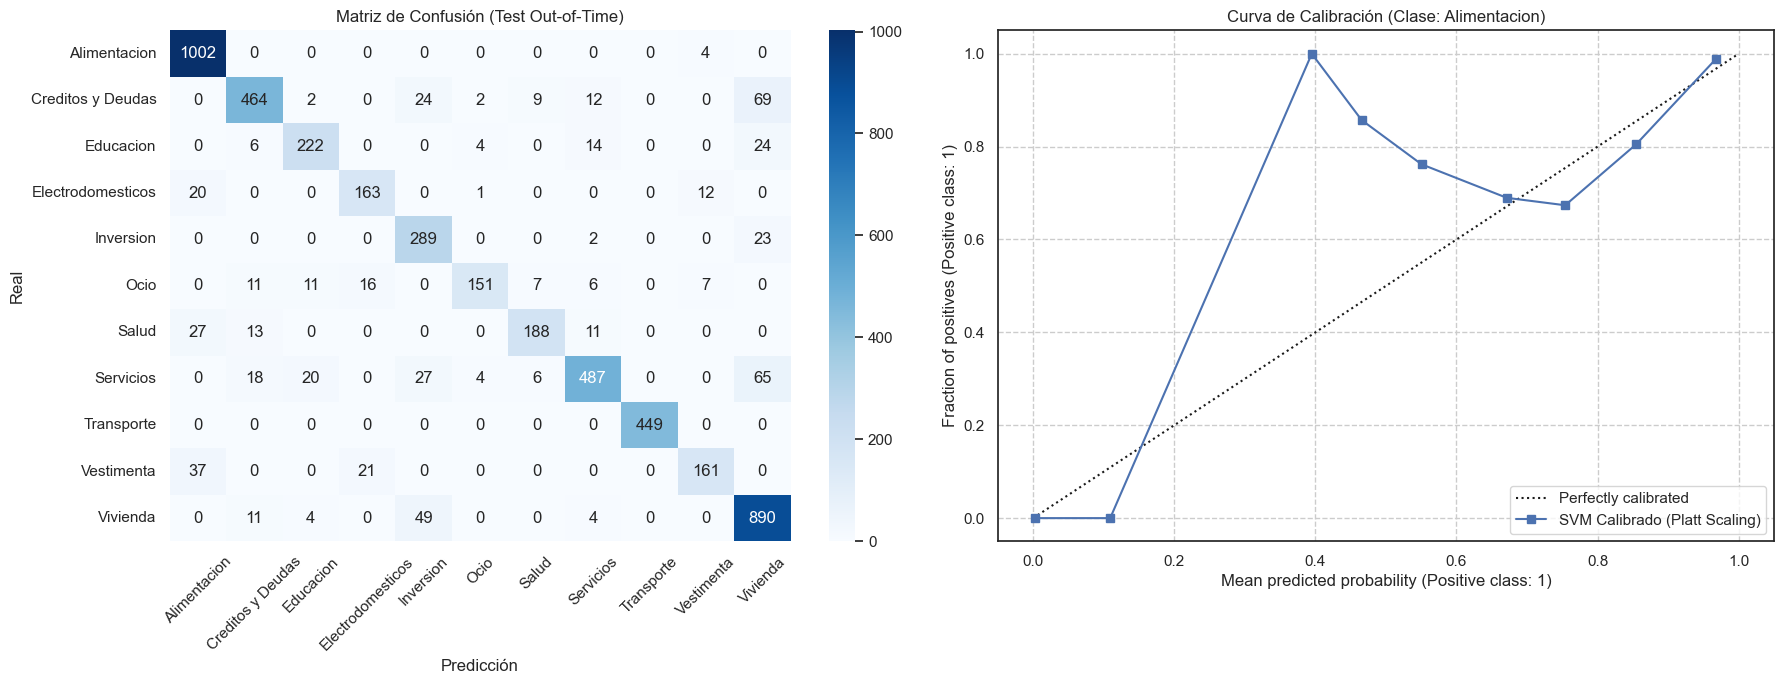

In [4]:
# =============================================================================
# 4. DIAGNOSTICO NLP: METRICAS, MATRIZ DE CONFUSION Y CALIBRACION (RELIABILITY)
# =============================================================================
from sklearn.calibration import CalibrationDisplay

y_pred = best_nlp_model.predict(X_test)

print("Reporte de Clasificación NLP (Métricas Cuantitativas por Clase):\n")
print(classification_report(y_test, y_pred, digits=4))

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Grafico 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=best_nlp_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_nlp_model.classes_, yticklabels=best_nlp_model.classes_, ax=ax[0])
ax[0].set_title('Matriz de Confusión (Test Out-of-Time)')
ax[0].set_ylabel('Real')
ax[0].set_xlabel('Predicción')
ax[0].tick_params(axis='x', rotation=45)

# Grafico 2: Diagrama de Calibración
# Verificamos si la confianza predicha (ej. 80%) corresponde con el acierto real (80% accuracy)
clase_objetivo = 'Alimentacion'
# best_nlp_model.predict_proba devuelve una matriz (n_samples, n_classes).
# Extraemos la columna correspondiente a la clase objetivo
idx_clase = list(best_nlp_model.classes_).index(clase_objetivo)
y_prob_clase = best_nlp_model.predict_proba(X_test)[:, idx_clase]

CalibrationDisplay.from_predictions(
    (y_test == clase_objetivo).astype(int), y_prob_clase,
    n_bins=10, ax=ax[1], name="SVM Calibrado (Platt Scaling)"
)
ax[1].set_title(f'Curva de Calibración (Clase: {clase_objetivo})')
ax[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()


## 3.4 Stress Test (Out-of-Vocabulary)
Prueba manual de la robustez del modelo enfrentándolo a textos ambiguos o inéditos.

In [5]:
# =============================================================================
# 5. PRUEBA DE ESTRES OUT-OF-VOCABULARY (OOV) CON CASOS REALISTAS (11 CLASES)
# =============================================================================
# Evaluamos descripciones nunca antes vistas en el dataset de entrenamiento
# para verificar la capacidad de generalizacion del modelo ante textos nuevos y abreviaturas.
casos_oov = [
    ("Vivienda",          "MENSUALIDAD DEPARTAMENTO ZONA NORTE"),
    ("Alimentacion",      "MERCADITO DEL BARRIO ESQUINA"),
    ("Salud",             "ORTOPEDIA CLINICA PRIVADA CONSULTA"),
    ("Electrodomesticos", "HELADERA SAMSUNG CUOTA 01"),
    ("Inversion",         "COMPRA BONOS TESORO NACIONAL"),
    ("Educacion",         "ARANCEL UNIVERSIDAD PRIVADA"),
    ("Transporte",        "BOLETO SUBTE SUBE RECARGA"),
    ("Ocio",              "ENTRADA TEATRO COLON FUNCION"),
    ("Vestimenta",        "REMERA MARCA LOCAL PALERMO"),
    ("Servicios",         "TELEFONO FIJO RESIDENCIAL FACTURA"),
    ("Creditos y Deudas", "PAGO RESUMEN TARJETA VISA CREDITO"),
    ("Creditos y Deudas", "CUOTA PRESTAMO HIPOTECARIO BANCO"),
    # Casos con ruido extremo, marcas compuestas y ambigüedad
    ("Inversion",         "COMPRA CEDEARS APPLE BROKER"),
    ("Salud",             "FARMACITY VITAMINAS C"),
    ("Ocio",              "PAGO SUSCRIPCION JUEGOS ONLINE"),
    ("Educacion",         "PAGO CURSO UDEMY PYTHON"),
    ("Vivienda",          "CERRAJERIA URGENCIAS 24HS"),
    ("Alimentacion",      "VERDULERIA DON JOSE"),
    ("Servicios",         "PAGO TELECENTRO WIFI"),
    ("Electrodomesticos", "CASA DEL AUDIO AURICULARES"),
    ("Transporte",        "CARGA NAFTA YPF"),
    ("Vestimenta",        "LOCAL ROPA ZARA PREMIUM")
]

print(f"{'Categoría Real':20} {'Predicción':20} {'Confianza':10}")
print("-" * 55)
for cat_real, desc in casos_oov:
    desc_limpia = limpiar_texto(desc)
    pred = best_nlp_model.predict([desc_limpia])[0]
    prob = best_nlp_model.predict_proba([desc_limpia])[0].max()
    print(f"{cat_real:20} {pred:20} {prob*100:8.1f}%")



Categoría Real       Predicción           Confianza 
-------------------------------------------------------
Vivienda             Vivienda                 58.4%
Alimentacion         Alimentacion             95.3%
Salud                Salud                    92.6%
Electrodomesticos    Electrodomesticos        90.3%
Inversion            Inversion                69.5%
Educacion            Educacion                95.2%
Transporte           Transporte               97.8%
Ocio                 Ocio                     93.3%
Vestimenta           Vestimenta               49.4%
Servicios            Servicios                75.3%
Creditos y Deudas    Creditos y Deudas        97.1%
Creditos y Deudas    Creditos y Deudas        97.5%
Inversion            Inversion                62.6%
Salud                Alimentacion             80.3%
Ocio                 Ocio                     63.3%
Educacion            Educacion                96.5%
Vivienda             Alimentacion             41.4%
Aliment

## 3.5 Perfilador de Salud Financiera: Aprendizaje Sensible al Costo (*Cost-Sensitive Learning*)

En la evaluación de riesgo crediticio bancario, **el costo de los errores es asimétrico**:
* **Falso Negativo (Crítico / Costoso)**: Clasificar a un usuario `En riesgo` como `Saludable` puede traducirse en créditos incobrables, pérdidas de capital e insolvencia.
* **Falso Positivo (Conservador / Leve)**: Clasificar a un usuario `Saludable` como `En riesgo` genera una recomendación preventiva o de cautela, pero el capital financiero queda protegido.

Por esta razón, aplicamos **ponderación de muestras según costo financiero (*Sample Weights*)**:
Asignamos un peso relativo de penalización ($2.5\times$ para `En riesgo`, $1.2\times$ para `En observacion` y $1.0\times$ para `Saludable`) al entrenar nuestro estimador `HistGradientBoostingClassifier`. Esto optimiza el **Recall de la clase crítica** sin comprometer la exactitud global.


Ajustando modelo de perfilado financiero con pesos sensibles al costo...

Reporte de Clasificación del Perfilador Financiero (Ponderado por Costo):

                precision    recall  f1-score   support

En observacion     0.8000    0.8095    0.8047        84
     En riesgo     0.7895    0.7692    0.7792        39
     Saludable     0.8667    0.8667    0.8667        60

      accuracy                         0.8197       183
     macro avg     0.8187    0.8151    0.8169       183
  weighted avg     0.8196    0.8197    0.8196       183



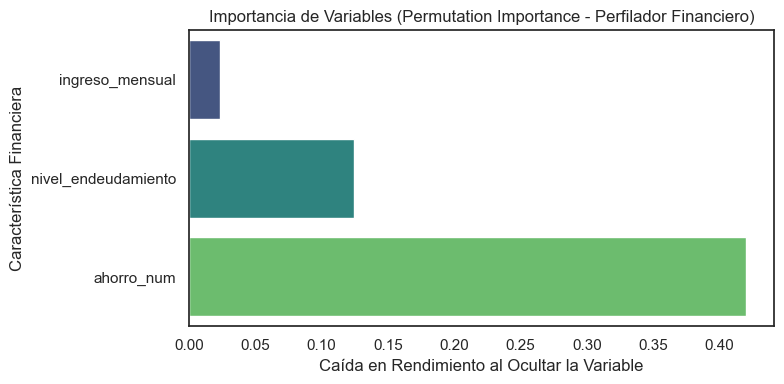

In [6]:
# =============================================================================
# 6. PERFILADOR FINANCIERO CON COST-SENSITIVE LEARNING (PESOS ASIMETRICOS)
# =============================================================================
df_u = pd.read_csv(f"{DATA_DIR}/usuarios.csv")
# Aprovechamos 'train' y 'val' para maximizar representatividad estadística sin tocar 'test'
train_u = df_u[df_u['split'].isin(['train', 'val'])].copy()
test_u = df_u[df_u['split'] == 'test'].copy()

# Mapeo ordinal de la frecuencia de ahorro a escala numérica [0.0 a 3.0]
mapeo_ahorro = {"NINGUNA": 0.0, "BAJA": 1.0, "MEDIA": 2.0, "ALTA": 3.0}
train_u["ahorro_num"] = train_u["frecuencia_ahorro"].map(mapeo_ahorro).fillna(0.0)
test_u["ahorro_num"] = test_u["frecuencia_ahorro"].map(mapeo_ahorro).fillna(0.0)

# Variables predictoras (features) y variable objetivo (target)
features = ["ingreso_mensual", "nivel_endeudamiento", "ahorro_num"]
X_tr_u, y_tr_u = train_u[features], train_u["perfil_financiero"]
X_te_u, y_te_u = test_u[features], test_u["perfil_financiero"]

# DEFINICION DE LA MATRIZ DE COSTOS FINANCIEROS (COST-SENSITIVE WEIGHTS)
# Castigamos 2.5 veces más el error en 'En riesgo' para proteger la cartera crediticia
pesos_costo_negocio = {
    "En riesgo": 2.5,
    "En observacion": 1.2,
    "Saludable": 1.0
}
sample_weights_train = y_tr_u.map(pesos_costo_negocio).values

# Pipeline del perfilador: normalizado con StandardScaler + ensamble Gradient Boosting regularizado
profiler_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", HistGradientBoostingClassifier(
        random_state=42,
        max_iter=150,
        max_leaf_nodes=31,
        l2_regularization=0.5,
        min_samples_leaf=20
    ))
])

print("Ajustando modelo de perfilado financiero con pesos sensibles al costo...")
# Pasamos sample_weight al estimador final a través de la sintaxis 'clf__sample_weight'
profiler_pipeline.fit(X_tr_u, y_tr_u, clf__sample_weight=sample_weights_train)

# Evaluamos métricas en el conjunto de prueba
y_pred_u = profiler_pipeline.predict(X_te_u)
print("\nReporte de Clasificación del Perfilador Financiero (Ponderado por Costo):\n")
print(classification_report(y_te_u, y_pred_u, digits=4))

# Permutation Importance: cuantifica el impacto real de cada variable en la decisión
r = permutation_importance(profiler_pipeline, X_te_u, y_te_u, n_repeats=10, random_state=42)

# Graficamos la importancia de las características
plt.figure(figsize=(8, 4))
sns.barplot(x=r.importances_mean, y=features, hue=features, palette='viridis', legend=False)
plt.title('Importancia de Variables (Permutation Importance - Perfilador Financiero)')
plt.xlabel('Caída en Rendimiento al Ocultar la Variable')
plt.ylabel('Característica Financiera')
plt.tight_layout()
plt.show()


## 3.6 Exportación a Producción
Serializamos los modelos finales usando `joblib` para ser consumidos por FastAPI.

In [7]:
import json
from datetime import datetime, timezone
from sklearn.metrics import f1_score

# Guardamos los pipelines completos en disco usando joblib.
# Al serializar el pipeline entero, el microservicio de FastAPI podra recibir texto crudo
# o valores numericos sin necesidad de reconfigurar vectorizadores o escaladores por separado.
joblib.dump(best_nlp_model, os.path.join(ARTIFACTS_DIR, "transaction_classifier.joblib"))
joblib.dump(profiler_pipeline, os.path.join(ARTIFACTS_DIR, "financial_profile_classifier.joblib"))

# Exportamos metadatos canónicos para que ml-service mantenga sincronía operativa
metadata = {
    "version": "2.0.0",
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "transaction_classifier": {
        "num_classes": len(best_nlp_model.classes_),
        "classes": list(best_nlp_model.classes_),
        "f1_macro_test": round(float(f1_score(y_test, y_pred, average='macro')), 4)
    },
    "financial_profiler": {
        "f1_weighted": round(float(f1_score(y_te_u, y_pred_u, average='weighted')), 4),
        "cost_sensitive_weight_risk": float(pesos_costo_negocio.get("En riesgo", 2.5))
    }
}

with open(os.path.join(ARTIFACTS_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"\n¡Modelos y metadatos exportados exitosamente a '{ARTIFACTS_DIR}'!")
print("- transaction_classifier.joblib")
print("- financial_profile_classifier.joblib")
print("- metadata.json")



¡Modelos exportados exitosamente a '../services/ml-service/app/artifacts'!
- transaction_classifier.joblib
- financial_profile_classifier.joblib


## 3.7 Conclusiones del Modelado
La combinación de `FeatureUnion` y `CalibratedClassifierCV` demuestra ser robusta ante el ruido, evitando el memorismo (*overfitting*) que mostraron modelos menos regulados. Asimismo, el `HistGradientBoostingClassifier` captura eficientemente la lógica de riesgo difuso que implementamos en la simulación.